In [32]:
## importing libraries 
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [33]:
df[['job_title_short','job_skills']].head(10)

,job_title_short,job_skills
0,Senior Data Engineer,None
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."
5,Data Engineer,"[python, sql, gcp]"
6,Senior Data Engineer,"[sql, python, java, sql server, gcp, bigquery,..."
7,Data Engineer,"[sql, nosql, gcp, azure, aws, bigquery, databr..."
8,Business Analyst,"[excel, powerpoint, power bi]"
9,Data Scientist,"[sql, python, r, mongodb, mongodb, sql server,..."


In [34]:
df_exploded=df.explode('job_skills')

<Axes: xlabel='job_skills'>

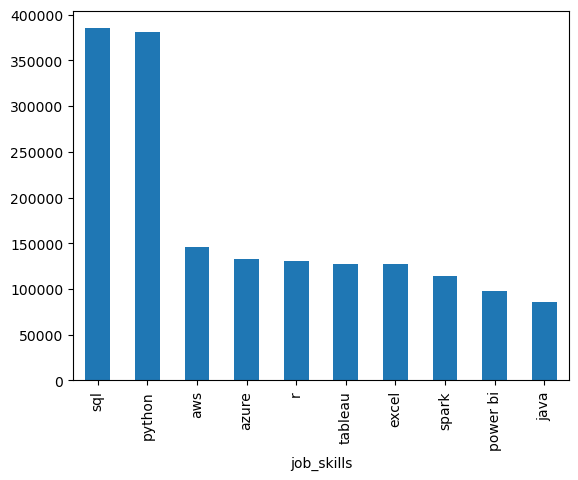

In [35]:
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

In [36]:
## group them by job title short & job skills 
skill_count=df_exploded.groupby(['job_title_short','job_skills']).size()

In [37]:
type(skill_count)
## convert the skill count from series to df 
df_skill_count=skill_count.reset_index(name='skill_count')
df_skill_count=df_skill_count.sort_values(by='skill_count',ascending=False)
df_skill_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


In [38]:
job_title='Data Engineer'
top_skills= 10

df_skill_final=df_skill_count[df_skill_count['job_title_short']== job_title].head(top_skills)
df_skill_final

,job_title_short,job_skills,skill_count
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
686,Data Engineer,aws,62049
687,Data Engineer,azure,60674
860,Data Engineer,spark,53656
763,Data Engineer,java,35559
770,Data Engineer,kafka,29073
755,Data Engineer,hadoop,28815
848,Data Engineer,scala,28716
712,Data Engineer,databricks,27477


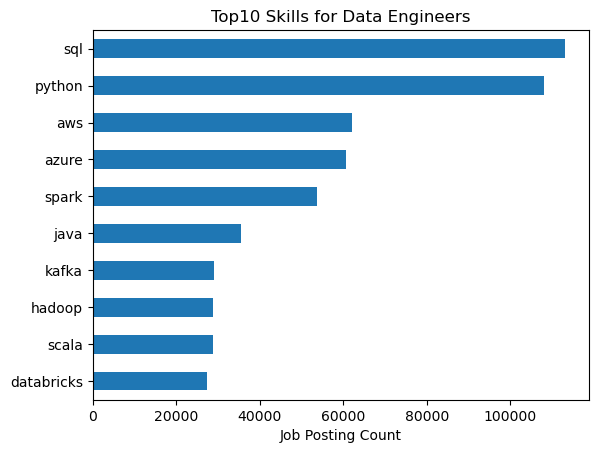

In [40]:
df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top{top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()
